<a href="https://colab.research.google.com/github/MuteebaAzhar/Meta-Analysis-Cochrane-Data/blob/main/eda_train.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
pip install biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 22.6 MB/s eta 0:00:00


In [9]:
# ----------------------------------------------
# 🧬 Step 2: Parse GO ontology
# ----------------------------------------------
!pip install obonet

import obonet
import networkx as nx
from google.colab import files
import matplotlib.pyplot as plt
import pandas as pd

# Upload the go-basic.obo file
uploaded = files.upload()

# Parse the ontology
obo_path = list(uploaded.keys())[0]
G = obonet.read_obo(obo_path)

print(f"✅ Parsed GO ontology successfully.")
print(f"Total terms (nodes): {len(G.nodes())}")
print(f"Total relations (edges): {len(G.edges())}")


Saving go-basic.obo to go-basic.obo
✅ Parsed GO ontology successfully.
Total terms (nodes): 40122
Total relations (edges): 77229


Step 1: Load all required libraries

In [11]:
# --------------------------------------------
# 🧩 Step 1: Import libraries
# --------------------------------------------
!pip install biopython obonet pandas matplotlib tqdm

from Bio import SeqIO
import pandas as pd
import obonet
import networkx as nx
from tqdm import tqdm


In [33]:
# Upload the files

from google.colab import files
uploaded = files.upload()


KeyboardInterrupt: 

Step 2: Define file paths

In [24]:
# --------------------------------------------
# 📂 Step 2: Define file paths
# --------------------------------------------
train_sequences_file = "train_sequences.fasta"
train_terms_file = "train_terms.tsv"
train_taxonomy_file = "train_taxonomy.tsv"
IA_file = "IA.tsv"
obo_file = "go-basic.obo"
go_obo_csv = "go_obo_ful.csv"  # your pre-extracted csv


Step 3: Load FASTA sequence

In [17]:
# --------------------------------------------
# 🧫 Step 3: Parse protein sequences
# --------------------------------------------
from Bio import SeqIO

seq_records = list(SeqIO.parse(train_sequences_file, "fasta"))

# Extract ID and sequence
protein_data = []
for record in seq_records:
    # FASTA header looks like: sp|A0A0C5B5G6|MOTSC_HUMAN ...
    header = record.id
    protein_id = header.split('|')[1] if '|' in header else header
    protein_data.append((protein_id, str(record.seq)))

# Create DataFrame
df_seq = pd.DataFrame(protein_data, columns=['Protein_ID', 'Sequence'])
print("✅ Sequences loaded:", df_seq.shape)
display(df_seq.head())


✅ Sequences loaded: (82404, 2)


,Protein_ID,Sequence
0,A0A0C5B5G6,MRWQEMGYIFYPRKLR
1,A0JNW5,MAGIIKKQILKHLSRFTKNLSPDKINLSTLKGEGELKNLELDEEVL...
2,A0JP26,MVAEVCSMPAASAVKKPFDLRSKMGKWCHHRFPCCRGSGKSNMGTS...
3,A0PK11,MPGWFKKAWYGLASLLSFSSFILIIVALVVPHWLSGKILCQTGVDL...
4,A1A4S6,MGLQPLEFSDCYLDSPWFRERIRAHEAELERTNKFIKELIKDGKNL...


Step 4: Load train_terms and train_taxonomy

In [19]:
# --------------------------------------------
# 🧾 Step 4: Load annotation & taxonomy data
# --------------------------------------------
df_terms = pd.read_csv(train_terms_file, sep='\t', names=['Protein_ID', 'GO_Term', 'Ontology'])
df_tax = pd.read_csv(train_taxonomy_file, sep='\t', names=['Protein_ID', 'Taxon_ID'])

print("✅ train_terms:", df_terms.shape)
print("✅ train_taxonomy:", df_tax.shape)


✅ train_terms: (537028, 3)
✅ train_taxonomy: (82404, 2)


Step 5: Load Gene Ontology (OBO) or flattened CSV

If you already have the CSV (go_obo_full.csv), use that instead of parsing the .obo (much faster).

In [26]:
# --------------------------------------------
# 📖 Step 5: Load GO Ontology data
# --------------------------------------------
df_go = pd.read_csv(go_obo_csv)
display(df_go.head())
print("✅ go_obo_df:", df_go.shape)

# Clean columns
df_go.rename(columns={'id':'GO_Term', 'name':'GO_Name', 'def':'GO_Definition'}, inplace=True)


,id,name,namespace,def,synonym,is_a,xref,alt_id,subset,relationship,comment
0,GO:0000001,mitochondrion inheritance,biological_process,"""The distribution of mitochondria, including t...","['""mitochondrial inheritance"" EXACT []']","['GO:0048308', 'GO:0048311']",NaN,NaN,NaN,NaN,NaN
1,GO:0000002,mitochondrial genome maintenance,biological_process,"""The maintenance of the structure and integrit...",NaN,['GO:0007005'],NaN,NaN,NaN,NaN,NaN
2,GO:0000006,high-affinity zinc transmembrane transporter a...,molecular_function,"""Enables the transfer of zinc ions (Zn2+) from...","['""high affinity zinc uptake transmembrane tra...",['GO:0005385'],NaN,NaN,NaN,NaN,NaN
3,GO:0000007,low-affinity zinc ion transmembrane transporte...,molecular_function,"""Enables the transfer of a solute or solutes f...",NaN,['GO:0005385'],NaN,NaN,NaN,NaN,NaN
4,GO:0000009,"alpha-1,6-mannosyltransferase activity",molecular_function,"""Catalysis of the transfer of a mannose residu...","['""1,6-alpha-mannosyltransferase activity"" EXA...",['GO:0000030'],"['Reactome:R-HSA-449718 ""Addition of a third m...",NaN,NaN,NaN,NaN


✅ go_obo_df: (40122, 11)


Step 6: Load IA.tsv (Information Accretion Weights)

In [27]:
# --------------------------------------------
# ⚖️ Step 6: Load IA weights
# --------------------------------------------
df_ia = pd.read_csv(IA_file, sep='\t', names=['GO_Term', 'IA_Weight'])
print("✅ IA.tsv loaded:", df_ia.shape)


✅ IA.tsv loaded: (40122, 2)


Step 7: Merge All DataFrames

Now we join everything step by step using inner joins (ensuring alignment).

In [28]:
# --------------------------------------------
# 🔗 Step 7: Merge datasets
# --------------------------------------------

# Merge 1: sequences + taxonomy
df_master = df_seq.merge(df_tax, on='Protein_ID', how='inner')

# Merge 2: add GO term annotations
df_master = df_master.merge(df_terms, on='Protein_ID', how='inner')

# Merge 3: add GO term names and definitions
df_master = df_master.merge(df_go[['GO_Term', 'GO_Name', 'namespace', 'GO_Definition']],
                            on='GO_Term', how='left')

# Merge 4: add IA weights
df_master = df_master.merge(df_ia, on='GO_Term', how='left')

print("✅ Final merged dataset:", df_master.shape)
df_master.head()


✅ Final merged dataset: (537027, 9)


,Protein_ID,Sequence,Taxon_ID,GO_Term,Ontology,GO_Name,namespace,GO_Definition,IA_Weight
0,A0A0C5B5G6,MRWQEMGYIFYPRKLR,9606,GO:0001649,P,osteoblast differentiation,biological_process,"""The process whereby a relatively unspecialize...",0.539639
1,A0A0C5B5G6,MRWQEMGYIFYPRKLR,9606,GO:0033687,P,osteoblast proliferation,biological_process,"""The multiplication or reproduction of osteobl...",6.480713
2,A0A0C5B5G6,MRWQEMGYIFYPRKLR,9606,GO:0005615,C,extracellular space,cellular_component,"""That part of a multicellular organism outside...",0.704771
3,A0A0C5B5G6,MRWQEMGYIFYPRKLR,9606,GO:0005634,C,nucleus,cellular_component,"""A membrane-bounded organelle of eukaryotic ce...",0.953496
4,A0A0C5B5G6,MRWQEMGYIFYPRKLR,9606,GO:0005739,C,mitochondrion,cellular_component,"""A semiautonomous, self replicating organelle ...",2.027294


from matplotlib import pyplot as plt
_df_0['IA_Weight'].plot(kind='hist', bins=20, title='IA_Weight')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
_df_1.groupby('GO_Term').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
_df_2.groupby('Ontology').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_15['Ontology'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_15, x='IA_Weight', y='Ontology', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_16['GO_Name'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_16, x='IA_Weight', y='GO_Name', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_17['namespace'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_17, x='IA_Weight', y='namespace', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

Step 8: Verify Alignment and Quality

In [29]:
# --------------------------------------------
# 📊 Step 8: Data quality checks
# --------------------------------------------
print("\nUnique proteins:", df_master['Protein_ID'].nunique())
print("Unique GO terms:", df_master['GO_Term'].nunique())
print("Unique taxa:", df_master['Taxon_ID'].nunique())

# Missing values summary
print("\nMissing values per column:\n", df_master.isna().sum())

# Ontology distribution
print("\nOntology distribution:\n", df_master['Ontology'].value_counts())

# Quick check for GO namespace consistency
print("\nNamespace distribution:\n", df_master['namespace'].value_counts())



Unique proteins: 82404
Unique GO terms: 26125
Unique taxa: 1381

Missing values per column:
 Protein_ID       0
Sequence         0
Taxon_ID         0
GO_Term          0
Ontology         0
GO_Name          0
namespace        0
GO_Definition    0
IA_Weight        0
dtype: int64

Ontology distribution:
 Ontology
P    250805
C    157770
F    128452
Name: count, dtype: int64

Namespace distribution:
 namespace
biological_process    250805
cellular_component    157770
molecular_function    128452
Name: count, dtype: int64


Step 9: Optional — Basic Exploratory PlotsStep 9: Optional — Basic Exploratory Plots

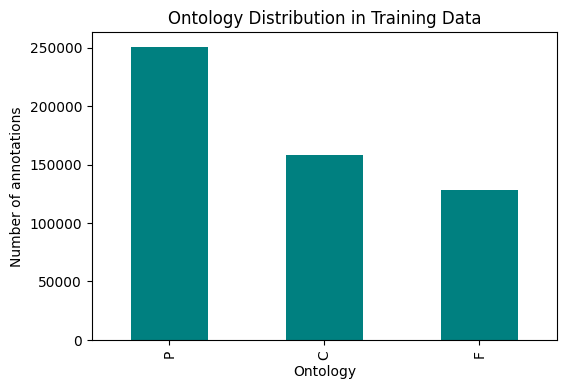

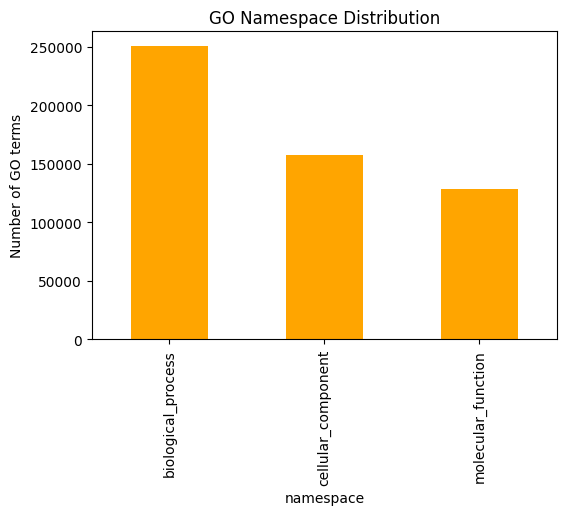

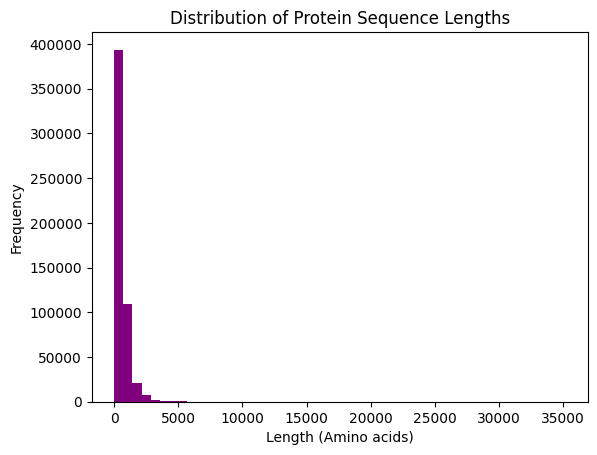

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
df_master['Ontology'].value_counts().plot(kind='bar', color='teal')
plt.title("Ontology Distribution in Training Data")
plt.ylabel("Number of annotations")
plt.show()

plt.figure(figsize=(6,4))
df_master['namespace'].value_counts().plot(kind='bar', color='orange')
plt.title("GO Namespace Distribution")
plt.ylabel("Number of GO terms")
plt.show()

# Sequence length distribution
df_master['Seq_Length'] = df_master['Sequence'].apply(len)
df_master['Seq_Length'].plot(kind='hist', bins=50, color='purple')
plt.title("Distribution of Protein Sequence Lengths")
plt.xlabel("Length (Amino acids)")
plt.show()


Step 10: Save the Final Aligned Dataset

In [31]:
# --------------------------------------------
# 💾 Step 10: Save final dataframe
# --------------------------------------------
df_master.to_csv("CAFA6_master_dataset.csv", index=False)
print("✅ Saved perfectly aligned dataset → CAFA6_master_dataset.csv")


✅ Saved perfectly aligned dataset → CAFA6_master_dataset.csv


In [34]:
from google.colab import files

# Save to CSV
df_master.to_csv("CAFA6_master_dataset.csv", index=False)
print("✅ Saved perfectly aligned dataset → CAFA6_master_dataset.csv")

# Download to your local computer
files.download("CAFA6_master_dataset.csv")


✅ Saved perfectly aligned dataset → CAFA6_master_dataset.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>